Importing a dataset with Cat and Dog images

In [3]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)

path.ls()

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 02:27&lt;00:00]</div>

[Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/annotations')]

Ignore the file path for now and get the files. 

In [4]:
files = get_image_files(path/"images")
len(files)

7390

So we need to differentiate between the cats and dogs, the dataset says that the first letter is a capital for cats and dogs is lwoer case so we just need to make a quick function to classify them

Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), 
Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/pug_52.jpg')

In [5]:
files[0:10]

[Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/pug_52.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/leonberger_6.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'), Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/shiba_inu_136.jpg')]

In [10]:
def label_func(f): 
    if f[0].isupper():
        return "Cat"
    else:
        return "Dog"

dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

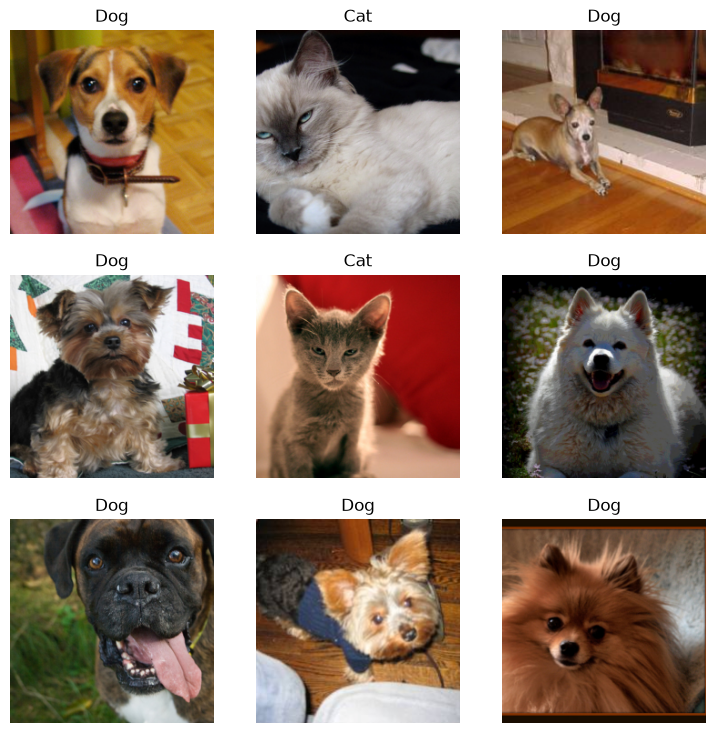

In [20]:
dls.show_batch()

In [12]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/shshankj/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:13<00:00, 6.66MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.138404,0.027100,0.011502,00:33


epoch,train_loss,valid_loss,error_rate,time
0,0.058552,0.020755,0.008119,00:37


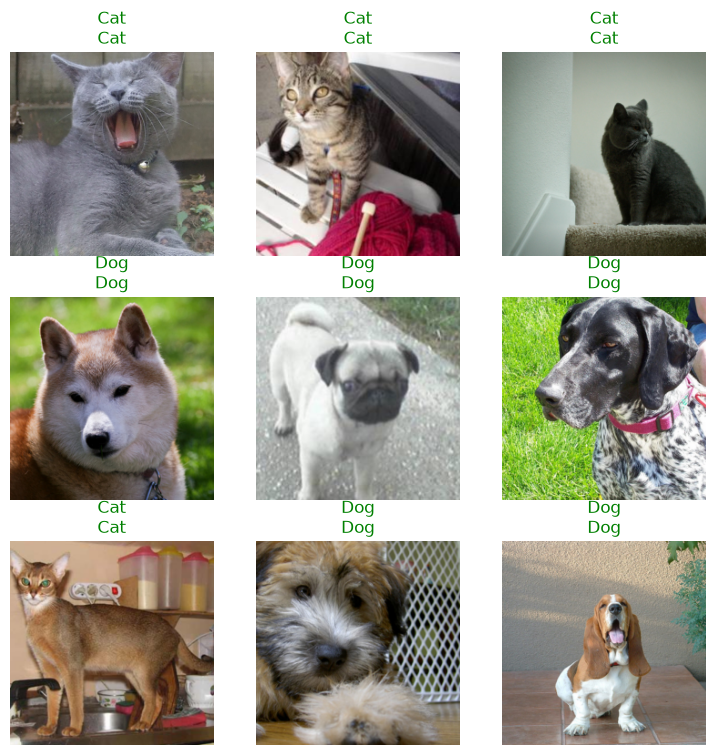

In [13]:
learn.show_results()

In [19]:
type, index, prob = learn.predict(files[0])

print(f"Its a: {type}")

print(f"I'm only {prob}% confident")

Its a: Cat
I'm only tensor([1.0000e+00, 1.8160e-12])% confident
